# Analyze synthetic network

In [444]:
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import csv
import shapely
import os


In [ ]:
directory = '/Users/6256481/Desktop/PhD_icloud/USA_UNC/work/river_hierarchy/synthetic/'

/var/folders/bs/xx1t3fn91jl3k26fn1pndd_c0000gn/T/ipykernel_37143/2434763434.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[0].boxplot(q_box_data, labels=bifs)
/var/folders/bs/xx1t3fn91jl3k26fn1pndd_c0000gn/T/ipykernel_37143/2434763434.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1].boxplot(q_box_data, labels=bifs)


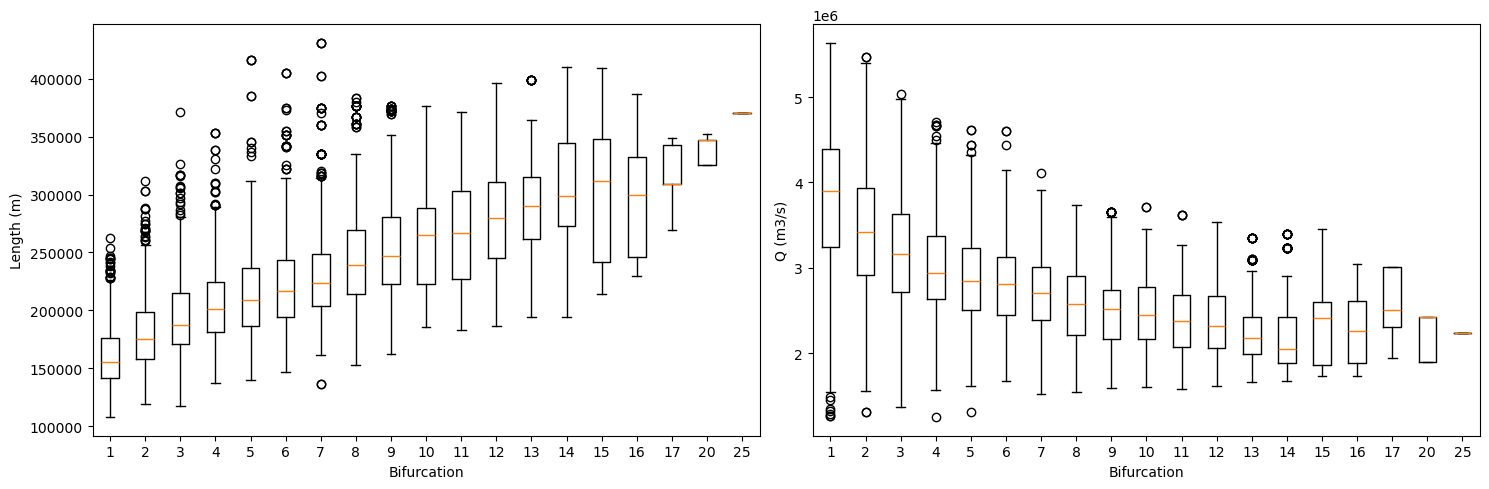

In [ ]:
# dirs = '/Users/6256481/Desktop/PhD_icloud/USA_UNC/work/river_hierarchy/synthetic/output/dl100000_dw5000_tw200/'
# df = pd.read_csv(dirs + 'averaged_random_15.csv')

f, ax = plt.subplots(ncols=2, figsize=(15, 5))

bifs = df['bifurcation'].unique()

# --- Left: boxplots of Q per bifurcation ---
q_box_data = [df.loc[df['bifurcation'] == b, 'length'] for b in bifs]
ax[0].boxplot(q_box_data, labels=bifs)
ax[0].set_xlabel("Bifurcation")
ax[0].set_ylabel("Length (m)")

# --- Left: boxplots of Q per bifurcation ---
q_box_data = [df.loc[df['bifurcation'] == b, 'Q'] for b in bifs]
ax[1].boxplot(q_box_data, labels=bifs)
ax[1].set_xlabel("Bifurcation")
ax[1].set_ylabel("Q (m3/s)")

# # --- Right: scatter + horizontal length boxes at mean Q ---
# Q_min, Q_max = df['Q'].min(), df['Q'].max()
# Q_range = Q_max - Q_min

# for b in bifs:
#     rows = df[df['bifurcation'] == b]

#     mean_len = rows['length'].mean()
#     mean_Q   = rows['Q'].mean()

#     # scatter point
#     ax[1].scatter(mean_len, mean_Q, label=str(b), zorder=3)

#     # horizontal boxplot of length, centered around this Q
#     ax[1].boxplot(
#         rows['length'],
#         vert=False,
#         positions=[mean_Q],                       # y = Q position
#         widths=0.03 * Q_range                    # small vertical thickness
#     )

# ax[1].set_xlabel("Length")
# ax[1].set_ylabel("Q")
# ax[1].legend()
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
from scipy.optimize import curve_fit

def exp_decay(t, A, tau, C):
    """Exponential decay model: y = A * exp(-t/tau) + C."""
    return A * np.exp(-t / tau) + C

def fit_efolding(time, values):
    """
    Fits an exponential decay to the data and returns:
    - tau (the e-folding time)
    - params (A, tau, C)
    """
    # Initial guesses
    A0 = values.max() - values.min()
    tau0 = (time.max() - time.min()) / 2
    C0 = values.min()

    popt, _ = curve_fit(exp_decay, time, values, p0=[A0, tau0, C0])

    A, tau, C = popt
    return tau, popt

In [32]:
# import xarray as xr
from glob import glob
import netCDF4
import numpy as np
from glob import glob
import pyarrow.parquet as pq
import pyarrow as pa
import pyarrow.compute as pc
import pyarrow.dataset as ds

files = sorted(glob('/Users/6256481/NoIcloudTemp/'+"*determined*.nc"))

In [ ]:
def equilibrium_height(Q):

    # build a histogram of the values
    counts, bin_edges = np.histogram(Q, bins=50)  # you can change 50

    # bin with the most samples
    idx = np.argmax(counts)

    # estimate “height” as the center of that bin
    eqh = 0.5 * (bin_edges[idx] + bin_edges[idx+1])
    return eqh


In [27]:
def plot_hydro(bif, frac, dfAv,bif_first = True):
    vals = []
    if bif_first:
        b_vals = bif
        i_vals = frac
    else:
        b_vals = frac
        i_vals = bif
    for b in b_vals:
        plt.figure(figsize = [15,7])
        if bif_first:
            save_name = 'bif'
        else:
            save_name = 'rpb'
        for i in i_vals:
            if bif_first:
                bi,fr = b, i
                tit = 'Bifurcations:'
            else:
                bi,fr = i, b
                tit = 'Reaches before bifurcation:'

            file   = glob(f'/Users/6256481/NoIcloudTemp/Qout_MS_b82_20150101_20240531_GLDASv21_ens_dtR10800determined_reach_1_{bi}_{fr}.nc')[0]
            with netCDF4.Dataset(file) as ds:
                qout = ds["Qout"][:]          # shape (time, rivid)
                rivid = ds["rivid"][:]        # river IDs
                times = ds["time"][:]         # time axis (check ds["time"].units)
            Q = qout[:,-1]

            # row = dfAv.loc[(dfAv['bifurcation'] == bi) & (dfAv['bif_frac_up'] == fr)].iloc[0]
            row = dfAv.loc[(dfAv['bifurcation'] == bi) & (dfAv['reach_per_break'] == fr)].iloc[0]
            dt = row['dt']
            # print(row)
            time_to_peak = row['step_duration_0'] + row['step_duration_1']+\
                            row['step_duration_2'] + row['step_duration_3']


            valDict = {}
            # end
            startloc = np.where(Q>1)[0][0]
            # print(startloc, Q[-20:])
            peakloc   = np.argmax(Q)
            Qs = Q[startloc:]
            endloc = np.where(Qs<1)[0][0] + startloc
            valDict['End'] = endloc * dt
            valDict['area_total'] =row['area_total']
            valDict['length_total'] =row['length_total']
            valDict['area_bif'] =row['area_bif']
            valDict['length_bif'] =row['length_bif']
            valDict['peak_delay'] = (peakloc *dt) - time_to_peak

            #equlibrium
            eqh = equilibrium_height(Q[startloc:peakloc])
            valDict['equilibrium'] = eqh
            
            # peak 
            valDict['peak'] = Q[peakloc]
            valDict['time_to_peak'] = peakloc*dt

            # above equili
            valDict['peak_above'] = Q[peakloc] - eqh
            valDict['bifurcation'] = b
            valDict['bif_frac'] = i

            # if bif != 0:
            M = peakloc
            V = Q[M:endloc+1]
            
            # print(bi, fr, M, endloc,len(V))
            X = np.arange(0, dt*len(V), dt)
            valDict['e-folding'] = fit_efolding(X, V)[0]
            # else:
            #     valDict['e-folding'] =0
            vals.append(valDict)
            if (bi == 0) & (i> 1):
                continue
            plt.scatter(np.arange(len(Q))*dt /3600,Q, s = 3, label = f'{i}')
            
            # print(row['step_duration_0']/3600, (row['step_duration_0']+row['step_duration_1'])/3600)
            plt.axhline(0, color = 'black', linewidth = 0.5)
            plt.axvline((row['step_duration_0'])/3600, color = 'red', linewidth = 0.5, linestyle = '--')
            plt.axvline((row['step_duration_0']+row['step_duration_1'])/3600, color = 'green', linewidth = 0.5, linestyle = '--')
            plt.axvline((row['step_duration_0']+row['step_duration_1']+row['step_duration_2'])/3600
                        , color = 'yellow', linewidth = 0.5, linestyle = '--')
            plt.axvline((time_to_peak)/3600, color = 'cyan', linewidth = 0.5, linestyle = '--')
            plt.axvline((time_to_peak+row['step_duration_4'])/3600, color = 'black', linewidth = 0.5, linestyle = '--')


        plt.xlim([0,2000])
        plt.ylabel('Discharge (m3/s)', fontsize = 15)
        plt.xlabel('Time (hour)', fontsize = 15)
        plt.title(f"{tit} {b}",fontsize = 20)
        plt.xticks(fontsize=14)
        plt.yticks(fontsize=14)
        plt.legend(fontsize = 15)
        folder_path = avDirP + f'figures/dl{dl}_dw{dw}_tw{tw}/'
        os.makedirs(folder_path, exist_ok=True)
        plt.savefig(folder_path + f'{save_name}{b}.png')
        plt.show()
    dfVals = pd.DataFrame(vals)
    return dfVals, qout

dl = 100000
dw = 5000
tw = 100
network = 'determined_reach_rw'
avDirP = f'/Users/6256481/Desktop/PhD_icloud/USA_UNC/work/river_hierarchy/synthetic/output/'
avDir = avDirP + f'dl{dl}_dw{dw}_tw{tw}/'
dfAv = pd.read_csv(avDir + f'network_values_{network}.csv')
# print(dfAv.head())
# A = list(np.arange(0.16,0.35,0.01))
# B = [float(np.round(a,2)) for a in A]
# B = np.arange(1,16,1)
# bif = np.arange(0,16,1)
# # bif = [8]
# dfVals, q = plot_hydro(bif, B
#                        ,dfAv, True)



In [33]:
dataset = ds.dataset(avDir + f"q_values_{network}.parquet", format="parquet")

# Pushdown filtering (very fast)
filtered = dataset.to_table(
    filter = (ds.field("bif") == 1) & (ds.field("seed") < 1)
)
filtered

pyarrow.Table
Q: float
seed: int64
bif: int64
reaches_per_break: int64
network: string
----
Q: [[]]
seed: [[]]
bif: [[]]
reaches_per_break: [[]]
network: [[]]

In [41]:
table = pq.read_table(avDir + f"q_values_{network}.parquet")
table

pyarrow.Table
Q: float
seed: int64
bif: int64
reaches_per_break: int64
network: string
----
Q: [[0,0,0,0,0,...,0,0,0,0,0]]
seed: [[1,1,1,1,1,...,10,10,10,10,10]]
bif: [[0,0,0,0,0,...,1,1,1,1,1]]
reaches_per_break: [[1,1,1,1,1,...,1,1,1,1,1]]
network: [["determined_reach_rw","determined_reach_rw","determined_reach_rw","determined_reach_rw","determined_reach_rw",...,"determined_reach_rw","determined_reach_rw","determined_reach_rw","determined_reach_rw","determined_reach_rw"]]

In [31]:
mask = pc.and_(
    pc.equal(table["bif"], 1),
    pc.equal(table["reaches_per_break"], 1),
    pc.equal(table["seed"], 1)
)
filtered = table.filter(mask)
filtered

TypeError: and_ takes 2 positional argument(s), but 3 were given

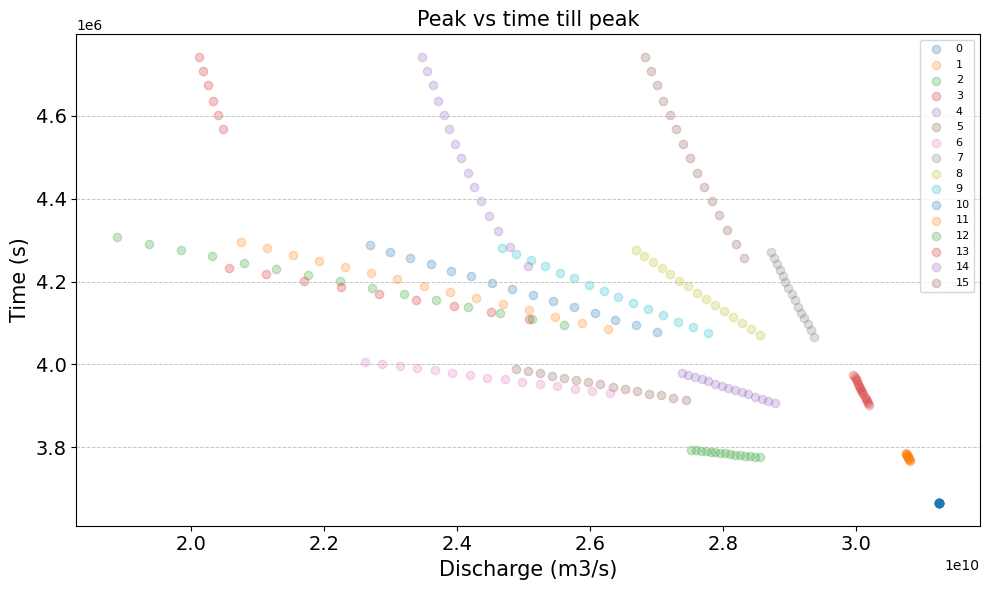

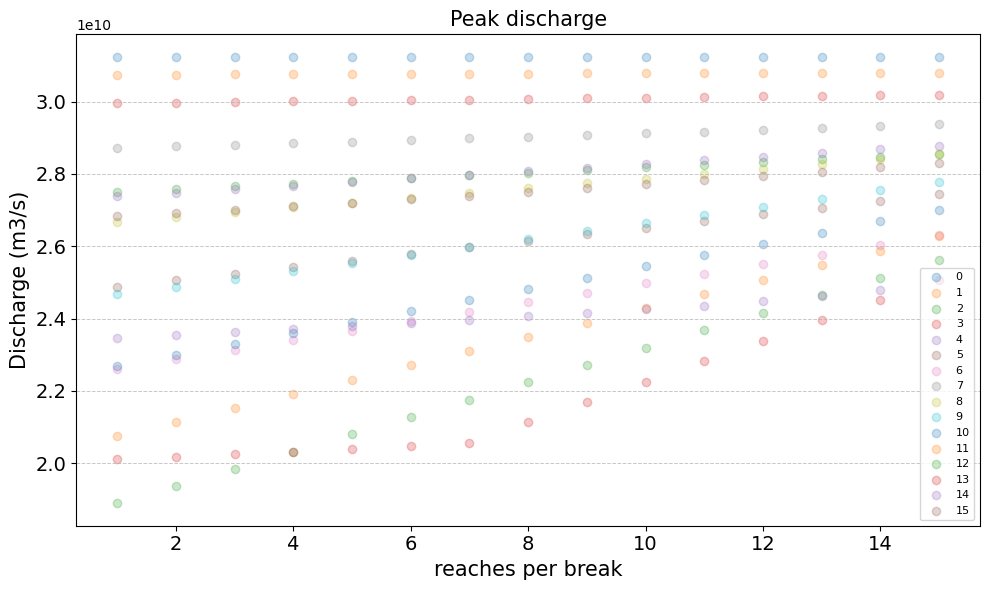

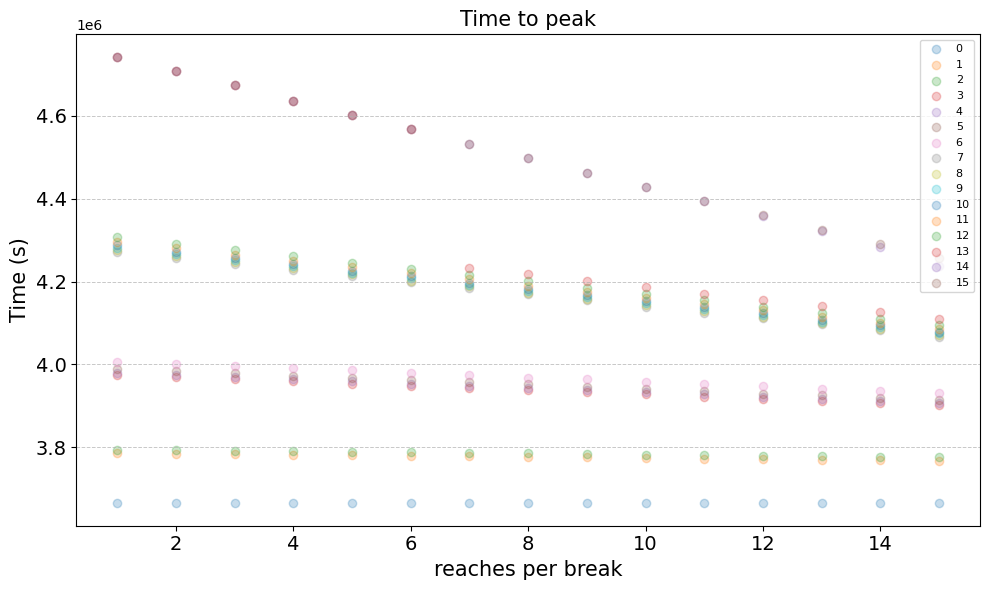

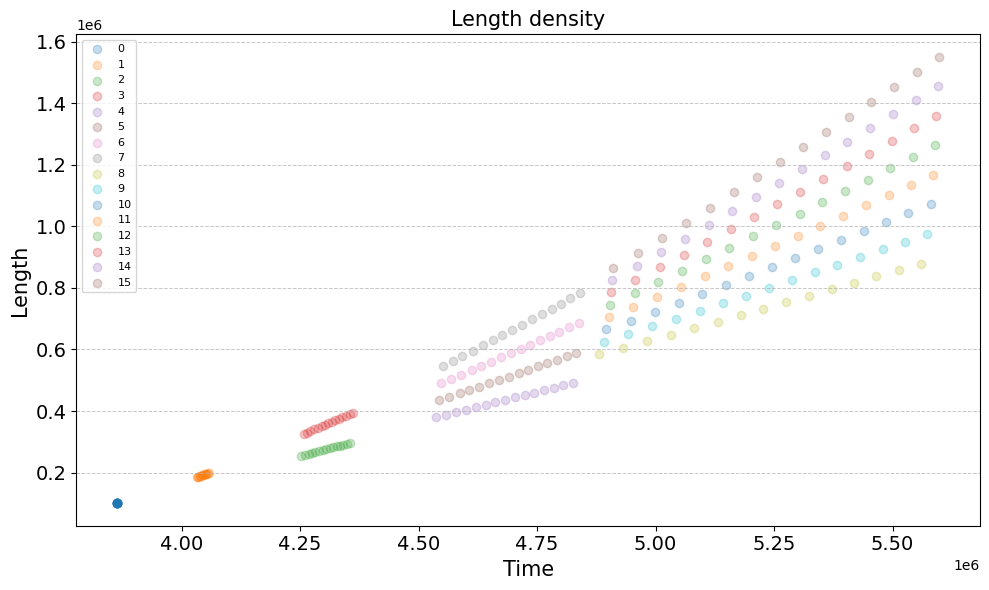

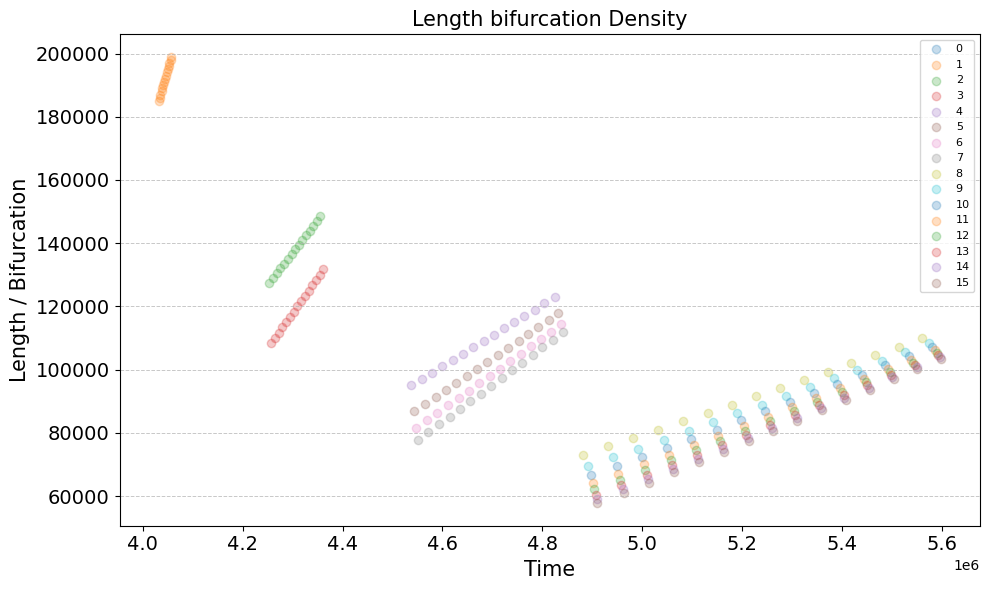

In [ ]:
def reg_plots(x, y, xlab, ylab, title):
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 6))

    for b in dfVals['bifurcation'].unique():
        # if b in [5,6,10,12]:
            # continue
        d = dfVals[dfVals['bifurcation'] == b]

        # ----------------------------
        # 1) Linear Regression (subplot 0)
        # ----------------------------
        # ax[0].scatter(d['bif_frac'], d[y], label=b, alpha=0.5)

        # if len(d) >= 2:
        #     x_lin = np.linspace(d['bif_frac'].min(), d['bif_frac'].max(), 100)
        #     coeff_lin = np.polyfit(d['bif_frac'], d[y], 1)
        #     y_lin_pred = np.polyval(coeff_lin, d['bif_frac'])

        #     ss_res = np.sum((d[y] - y_lin_pred)**2)
        #     ss_tot = np.sum((d[y] - d[y].mean())**2)
        #     r2_lin = 1 - ss_res/ss_tot if ss_tot != 0 else np.nan

        #     ax[0].plot(x_lin, np.polyval(coeff_lin, x_lin),
        #             linestyle='--', 
        #             label=f"{b} linear R2={r2_lin:.2f}")

        # ----------------------------
        # 2) Quadratic Regression (subplot 1)
        # ----------------------------

        ax.scatter(d[x], d[y], alpha=0.25, label=f"{b}")

        # if len(d) >= 3:

        #     x_quad = np.linspace(d[x].min(), d[x].max(), 100)
        #     coeff_quad = np.polyfit(d[x], d[y], 2)
        #     y_quad_pred = np.polyval(coeff_quad, d[x])


        #     ss_res2 = np.sum((d[y] - y_quad_pred)**2)
        #     ss_tot2 = np.sum((d[y] - d[y].mean())**2)
        #     r2_quad = 1 - ss_res2/ss_tot2 if ss_tot2 != 0 else np.nan

        #     ax.plot(x_quad, np.polyval(coeff_quad, x_quad), 
        #             linestyle='-.',
        #             label=f"{b} R2={r2_quad:.2f}", alpha = 0.5)

    # Final labels
    ax.set_xlabel(xlab, fontsize = 15)
    ax.set_ylabel(ylab, fontsize = 15)
    plt.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.7)

    ax.legend(fontsize = 8)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    # plt.xlim([0.94e7,1e7])
    # plt.ylim([4.8e6,6e6])
    plt.title(title, fontsize = 15)
    plt.tight_layout()
    plt.savefig(avDirP + f'figures/dl{dl}_dw{dw}_tw{tw}/{title}.png')
    plt.show()

reg_plots('peak', 'time_to_peak', 'Discharge (m3/s)','Time (s)', 'Peak vs time till peak')
reg_plots('bif_frac', 'peak', 'reaches per break','Discharge (m3/s)', 'Peak discharge')
reg_plots('bif_frac', 'time_to_peak', 'reaches per break','Time (s)', 'Time to peak')
reg_plots('End', 'length_total', 'Time', 'Length', 'Length density')
dfVals['LB'] = dfVals['length_total'] / dfVals['bifurcation']
reg_plots('End', 'LB', 'Time', 'Length / Bifurcation', 'Length bifurcation Density')



[0.16,
 0.17,
 0.18,
 0.19,
 0.2,
 0.21,
 0.22,
 0.23,
 0.24,
 0.25,
 0.26,
 0.27,
 0.28,
 0.29,
 0.3,
 0.31,
 0.32,
 0.33,
 0.34,
 0.35,
 0.36,
 0.37,
 0.38]

In [ ]:
dfVals

,End,equilibrium,peak,peak_above,bifurcation,bif_frac,e-folding
0,674,129727032.0,1.119460e+09,9.897333e+08,1,0.10,835.688451
1,633,147146192.0,1.335635e+09,1.188488e+09,1,0.15,567.497838
2,593,164539312.0,1.548070e+09,1.383530e+09,1,0.20,393.885270
3,552,181920544.0,1.755584e+09,1.573663e+09,1,0.25,321.247253
4,513,199298064.0,1.956438e+09,1.757140e+09,1,0.30,295.222098
5,450,234051792.0,2.329291e+09,2.095239e+09,1,0.40,291.949132
6,793,155393072.0,1.283978e+09,1.128585e+09,2,0.10,991.988109
7,707,175245504.0,1.529148e+09,1.353903e+09,2,0.15,739.511909
8,629,193382368.0,1.762968e+09,1.569586e+09,2,0.20,542.347261
9,566,209879312.0,1.983188e+09,1.773309e+09,2,0.25,426.814921


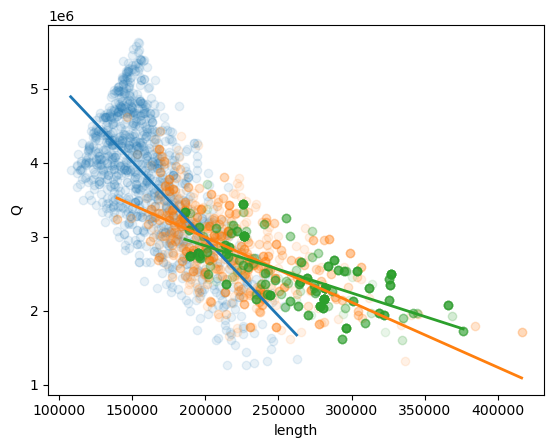

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

bif_values = [1,5, 10]      # bifurcation values to loop over
degrees    = [1]         # polynomial degrees you want to add

for b in bif_values:
    d = df[df['bifurcation'] == b]

    x = d['length'].values
    y = d['Q'].values

    # Scatter
    plt.scatter(x, y, label=f"bif={b}", alpha = 0.1)

    # Loop through polynomial degrees
    for deg in degrees:
        if len(x) > deg:  # need at least deg+1 points
            coeffs = np.polyfit(x, y, deg)

            # Make smooth line
            x_line = np.linspace(x.min(), x.max(), 200)
            y_line = np.polyval(coeffs, x_line)

            # Compute predicted y for R^2
            y_pred = np.polyval(coeffs, x)
            ss_res = np.sum((y - y_pred)**2)
            ss_tot = np.sum((y - np.mean(y))**2)
            r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan

            # Plot line with R²
            plt.plot(
                x_line, 
                y_line, 
                alpha=1,
                linewidth = 2,
                label=f"bif={b}, deg={deg}, R²={r2:.3f}"
            )

plt.xlabel("length")
plt.ylabel("Q")
# plt.legend()
plt.show()



In [ ]:
# plots general mean plot
# for single bifurcation ones plot the different runs with length sums

# lines for each determined plot

In [ ]:
dirs = '/Users/6256481/Desktop/PhD_icloud/USA_UNC/work/river_hierarchy/synthetic/output/dl100000_dw5000_tw200/'
df_det = pd.read_csv(dirs + 'averaged_determined.csv')
df_det.head()

,Unnamed: 0,bif_frac,length,bifurcation,Q,seed
0,0,0.10,180000.0,1,1518049.2,1
1,1,0.15,170000.0,1,1857920.9,1
2,2,0.20,160000.0,1,2178158.2,1
3,3,0.25,150000.0,1,2483173.2,1
4,4,0.30,140000.0,1,2776375.8,1


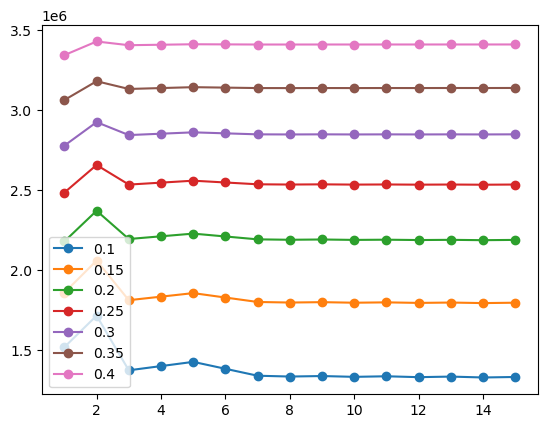

In [ ]:

for bf in df_det['bif_frac'].unique():
    d = df_det[df_det['bif_frac'] == bf]
    plt.plot(d['bifurcation'], d['Q'], label = bf, marker = 'o')
plt.legend()
plt.show()



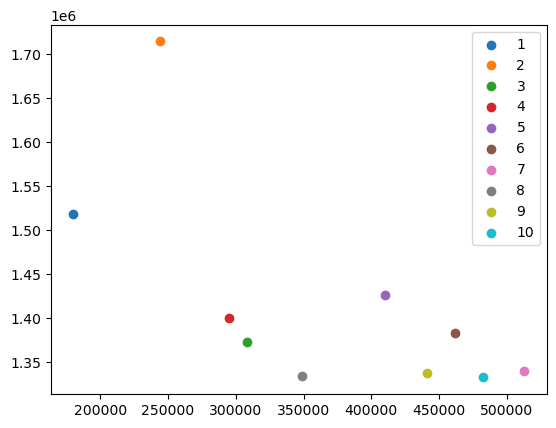

In [ ]:
for bf in df_det['bif_frac'].unique()[0:1]:
    d = df_det[df_det['bif_frac'] == bf]
    for bif in df_det['bifurcation'].unique()[0:10]:
        d2 = d[d['bifurcation'] == bif]
        plt.scatter(d2['length'], d2['Q'], label = bif)
plt.legend()
plt.show()

In [ ]:
from PIL import Image, ImageDraw

def generate_bifurcation_png(N, filename="tree.png"):
    """
    Creates a bifurcation tree drawing with N diamonds and exports it as a PNG.
    """

    # Canvas size (expand with N)
    width = 800
    height = 400 + N * 250

    # Create a white background
    img = Image.new("RGB", (width, height), "white")
    draw = ImageDraw.Draw(img)

    # Geometry settings
    trunk_length = 100
    diamond_width = 160
    diamond_height = 200

    # Start point (root)
    x0, y0 = width // 2, 50

    # Draw root trunk
    draw.line((x0, y0, x0, y0 + trunk_length), fill="#162A70", width=4)

    # Current center after root trunk
    cx, cy = x0, y0 + trunk_length

    def draw_diamond(center_x, top_y, w, h):
        """
        Draws a diamond centered around (center_x, top_y + h/2).
        Returns the bottom point of the diamond.
        """
        cx = center_x
        cy = top_y + h / 2

        top = (cx, top_y)
        right = (cx + w/2, cy)
        bottom = (cx, top_y + h)
        left = (cx - w/2, cy)

        # Draw diamond
        draw.line((top, right), fill="#162A70", width=4)
        draw.line((right, bottom), fill="#162A70", width=4)
        draw.line((bottom, left), fill="#162A70", width=4)
        draw.line((left, top), fill="#162A70", width=4)

        return bottom

    # Draw N diamonds
    for i in range(N):
        bottom = draw_diamond(cx, cy, diamond_width, diamond_height)

        # draw trunk down to next diamond
        draw.line(
            (bottom[0], bottom[1], bottom[0], bottom[1] + trunk_length),
            fill="#162A70", width=4
        )

        # move center to next trunk end
        cy = bottom[1] + trunk_length

    # bottom root trunk
    draw.line((cx, cy, cx, cy + trunk_length), fill="#162A70", width=4)

    # Save PNG
    img.save(filename)
    print(f"PNG written to {filename}")


# -------------------------
# Example usage:
# -------------------------

generate_bifurcation_png(2, "bifurcation_2.png")


PNG written to bifurcation_2.png


In [ ]:
glob(fdir + '*reaches*.gpkg')[0]

'oc'

In [ ]:
fdir = '/Users/6256481/Desktop/PhD_icloud/USA_UNC/work/data/'
for f in glob(fdir + '*reaches*.gpkg'):
    gdf = gpd.read_file(f)
    gdf = gdf[['reach_id', 'geometry']]
    # Output shapefile path
    shp_path = f"{f.split('/')[-1].split('_')[0]}.shp"

    # Save as Shapefile with same CRS
    gdf.to_file('/Users/6256481/Desktop/PhD_icloud/USA_UNC/work/data/shp/'+ shp_path, driver="ESRI Shapefile")

In [5]:
import pandas as pd
import geopandas as gpd
from glob import glob
from tqdm import tqdm

In [21]:
D = '/Volumes/PhD/SWORD/v17/'
files = glob(D + '*reaches*.gpkg')
for i, f in tqdm(enumerate(files), total= len(files) ):
    dt = gpd.read_file(f)
    if i == 0:
        DT1 = dt
    else:
        DT1 = pd.concat([DT1, dt])

100%|██████████| 6/6 [00:26<00:00,  4.43s/it]


In [23]:
DT1.reach_len.mean(), DT1.reach_len.max(), DT1.shape[0]

(np.float64(8876.797714060775), 34853.57032380043, 248673)

In [7]:
D = '/Volumes/PhD/confinement/results/new_segments/vector/'
files = glob(D + '*')
for i, f in tqdm(enumerate(files), total= len(files) ):
    dt = gpd.read_file(f)
    if i == 0:
        DT = dt
    else:
        DT = pd.concat([DT, dt])

  0%|          | 0/43 [00:00<?, ?it/s]

100%|██████████| 43/43 [00:07<00:00,  5.89it/s]


In [19]:
DT.reach_len.mean(), DT.reach_len.max()

(np.float64(8879.575301668789), 91040.63117065883)

In [18]:

DT['combined_reach_len'].unique().mean(),DT['combined_reach_len'].unique().max()

(np.float64(11756.923863563476), np.float64(469771.237902879))